In [61]:
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [62]:
device = "cuda"

In [63]:
data = np.load("Data/crazydata.npz")

In [64]:
X = data["X"]
y = data["Y"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [66]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return (
            self.X[index].unsqueeze(0),
            self.y[index].unsqueeze(0)
        )


In [67]:
train_dataset = dataset(X_train, y_train)
test_dataset = dataset(X_test, y_test)

In [68]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [69]:
class NeuralNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        
        self.conv2 = nn.Conv2d(16,16,3,padding=1)

        self.conv3 = nn.Conv2d(16,1,3,padding=1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)

        return x

In [70]:
model = NeuralNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [71]:
print(model)

NeuralNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
)


In [72]:
epochs = 20
loss_over_epochs = []
for epoch in range(epochs):
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()
        avg_loss = running_loss / len(train_dataloader)
        loss_over_epochs.append(avg_loss)

    print(f"epoch {epoch+1}: loss = {avg_loss}")

epoch 1: loss = 0.022522798593801314
epoch 2: loss = 2.486603814785277e-05
epoch 3: loss = 1.7372335157866863e-06
epoch 4: loss = 1.5327201822746668e-07
epoch 5: loss = 1.5046032080550426e-08
epoch 6: loss = 1.7436066588121564e-09
epoch 7: loss = 3.0746850729147986e-10
epoch 8: loss = 1.1177544564624656e-10
epoch 9: loss = 6.594738597372394e-11
epoch 10: loss = 4.7578420145355516e-11
epoch 11: loss = 3.813990043322454e-11
epoch 12: loss = 3.268080463232031e-11
epoch 13: loss = 2.8602921447075976e-11
epoch 14: loss = 2.5743960502850566e-11
epoch 15: loss = 2.3507616367082366e-11
epoch 16: loss = 2.1785955498995756e-11
epoch 17: loss = 2.0351929197867262e-11
epoch 18: loss = 1.9087031913978378e-11
epoch 19: loss = 1.7950581420396658e-11
epoch 20: loss = 1.711040436305568e-11


In [73]:
model.eval()
with torch.no_grad():
    X_batch, y_batch = next(iter(test_dataloader))

    X_batch = X_batch.to(device)
    predictions = model(X_batch)
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()

In [86]:
X_batch[1].shape

torch.Size([1, 32, 32])

Text(0.5, 1.0, 'Prediction')

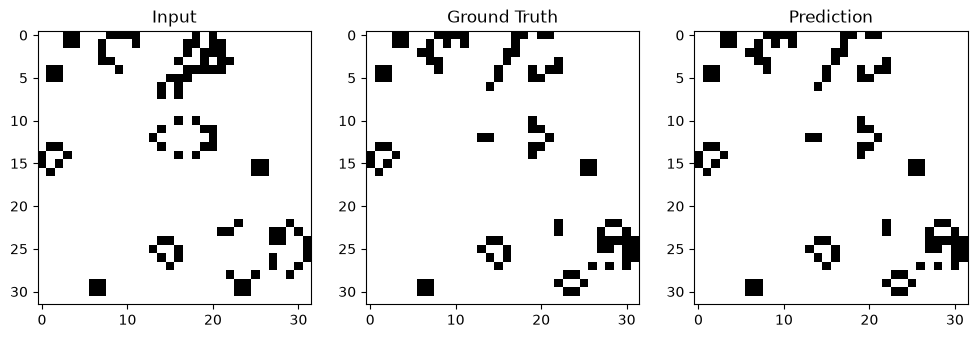

In [89]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))

idx = 14
ax[0].imshow(
    X_batch[idx][0].cpu(),
    cmap="binary"
)
ax[0].set_title("Input")

ax[1].imshow(
    y_batch[idx][0],
    cmap="binary"
)
ax[1].set_title("Ground Truth")

ax[2].imshow(
    predictions[idx][0].cpu(),
    cmap="binary"
)
ax[2].set_title("Prediction")

In [116]:
board = np.random.randint(0, 2, (200, 200))

board = torch.tensor(board, dtype=torch.float32)
board = board.unsqueeze(0).unsqueeze(0).to(device)

In [120]:
torch.save(model.state_dict(), "game_of_life_cnn.pth")